In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from xgboost import XGBRegressor

In [ ]:
BASE = Path("/content/drive/MyDrive/pruebas/pre")

EMB_DIR = BASE / "embeddings" / "embeddings_w2v"
SPEC_DIR = BASE / "spectral_feats"

TR_W2V = EMB_DIR / "train_embeddings_w2v.npz"
VA_W2V = EMB_DIR / "val_embeddings_w2v.npz"
TE_W2V = EMB_DIR / "test_embeddings_w2v.npz"

TR_SPEC = SPEC_DIR / "train_spectral.npz"
VA_SPEC = SPEC_DIR / "val_spectral.npz"
TE_SPEC = SPEC_DIR / "test_spectral.npz"

In [ ]:
def load_embed_npz(npz_path: Path):
    D = np.load(npz_path, allow_pickle=True)

    Xw = D["Xw"].astype(np.float32)
    zrms_log = D["zrms_log"].astype(np.float32).reshape(-1, 1)

    meta = pd.DataFrame({
        "path": D["path"].astype("U"),
        "clip_id": D["clip_id"].astype("U"),
        "start_samp": D["start_samp"].astype(np.int64),
        "end_samp": D["end_samp"].astype(np.int64),
        "valence": D["valence"].astype(np.float32),
        "arousal": D["arousal"].astype(np.float32),
        "dominance": D["dominance"].astype(np.float32),
        "win_rms": D["win_rms"].astype(np.float32),
        "zrms_log": D["zrms_log"].astype(np.float32),
    })
    return Xw, zrms_log, meta

In [ ]:
def ccc2(y_true, y_pred):
    y_true_mean = np.mean(y_true)
    y_pred_mean = np.mean(y_pred)
    covariance = np.mean((y_true - y_true_mean) * (y_pred - y_pred_mean))
    true_var = np.var(y_true)
    pred_var = np.var(y_pred)
    return (2 * covariance) / (true_var + pred_var + (y_true_mean - y_pred_mean) ** 2 + 1e-8)

In [ ]:
def load_spec_npz(npz_path: Path):
    D = np.load(npz_path, allow_pickle=True)

    Xspec = D["Xspec"].astype(np.float32)

    meta = pd.DataFrame({
        "path": D["path"].astype("U"),
        "clip_id": D["clip_id"].astype("U"),
        "start_samp": D["start_samp"].astype(np.int64),
        "end_samp": D["end_samp"].astype(np.int64),
    })
    return Xspec, meta

In [ ]:
def check_alignment(meta_a, meta_b, name="split"):
    ok = (
        (meta_a["path"].values == meta_b["path"].values).all() and
        (meta_a["clip_id"].values == meta_b["clip_id"].values).all() and
        (meta_a["start_samp"].values == meta_b["start_samp"].values).all() and
        (meta_a["end_samp"].values == meta_b["end_samp"].values).all()
    )
    print(name, "aligned:", ok)
    return ok

In [ ]:
def aggregate_trimmed_mean(df, preds, trim=0.1, true_col="arousal"):
    df = df.copy()
    df["pred"] = preds

    out = []

    for cid, g in df.groupby("clip_id"):
        p = np.sort(g["pred"].values.astype(np.float32))
        t = float(g[true_col].iloc[0])

        k = int(len(p) * trim)
        if len(p) > 2 * k and k > 0:
            p_use = p[k:-k]
        else:
            p_use = p

        if len(p_use) == 0:
            continue

        out.append((cid, float(np.mean(p_use)), t, len(p)))

    return pd.DataFrame(out, columns=["clip_id", "pred", "true", "n_windows"])

# Arousal — Carga de datos

In [ ]:
Xspec_tr, meta_spec_tr = load_spec_npz(TR_SPEC)
Xspec_va, meta_spec_va = load_spec_npz(VA_SPEC)
Xspec_te, meta_spec_te = load_spec_npz(TE_SPEC)

print(Xspec_tr.shape, Xspec_va.shape, Xspec_te.shape)

(38249, 8) (8459, 8) (9980, 8)


In [ ]:
Xw_tr, zrms_tr, meta_tr = load_embed_npz(TR_W2V)
Xw_va, zrms_va, meta_va = load_embed_npz(VA_W2V)
Xw_te, zrms_te, meta_te = load_embed_npz(TE_W2V)

print(Xw_tr.shape, zrms_tr.shape, Xspec_tr.shape)
print(Xw_va.shape, zrms_va.shape, Xspec_va.shape)
print(Xw_te.shape, zrms_te.shape, Xspec_te.shape)

(38249, 2048) (38249, 1) (38249, 8)
(8459, 2048) (8459, 1) (8459, 8)
(9980, 2048) (9980, 1) (9980, 8)


In [ ]:
check_alignment(meta_tr, meta_spec_tr, "train")
check_alignment(meta_va, meta_spec_va, "val")
check_alignment(meta_te, meta_spec_te, "test")

train aligned: True
val aligned: True
test aligned: True


np.True_

In [ ]:
X_tr = np.concatenate([Xw_tr, zrms_tr, Xspec_tr], axis=1).astype(np.float32)
X_va = np.concatenate([Xw_va, zrms_va, Xspec_va], axis=1).astype(np.float32)
X_te = np.concatenate([Xw_te, zrms_te, Xspec_te], axis=1).astype(np.float32)

print("X_tr:", X_tr.shape)
print("X_va:", X_va.shape)
print("X_te:", X_te.shape)

X_tr: (38249, 2057)
X_va: (8459, 2057)
X_te: (9980, 2057)


In [ ]:
mu_X = X_tr.mean(axis=0, keepdims=True)
sd_X = X_tr.std(axis=0, keepdims=True) + 1e-8

X_tr_n = (X_tr - mu_X) / sd_X
X_va_n = (X_va - mu_X) / sd_X
X_te_n = (X_te - mu_X) / sd_X

In [ ]:
# Target: AROUSAL
yA_tr = meta_tr["arousal"].to_numpy(np.float32)
yA_va = meta_va["arousal"].to_numpy(np.float32)
yA_te = meta_te["arousal"].to_numpy(np.float32)

y_mean = yA_tr.mean()
y_std  = yA_tr.std() + 1e-8

yA_tr_n = (yA_tr - y_mean) / y_std
yA_va_n = (yA_va - y_mean) / y_std

## Modelo base (best params valence como warm-start)

In [ ]:
params = {
    "learning_rate": 0.09989730695216865,
    "max_leaves": 63,
    "min_child_weight": 11.503343698077279,
    "subsample": 0.6154070311066155,
    "colsample_bytree": 0.6652044024893341,
    "colsample_bynode": 0.788136481728704,
    "gamma": 0.13549424394028625,
    "reg_alpha": 7.701025741480394,
    "reg_lambda": 47.55490206989469,
    "max_bin": 255,
    "device": "cuda",
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "n_estimators": 2000,
    "max_depth": 0,
    "grow_policy": "lossguide",
    "eval_metric": "rmse",
    "random_state": 42,
    "n_jobs": -1,
}

model_A2 = XGBRegressor(**params)

model_A2.fit(
    X_tr_n, yA_tr_n,
    eval_set=[(X_va_n, yA_va_n)],
    verbose=100
)

[0]	validation_0-rmse:0.92663
[100]	validation_0-rmse:0.80264
[200]	validation_0-rmse:0.79834
[300]	validation_0-rmse:0.79875
[400]	validation_0-rmse:0.80013
[500]	validation_0-rmse:0.80111
[600]	validation_0-rmse:0.80043
[700]	validation_0-rmse:0.80260
[800]	validation_0-rmse:0.80325
[900]	validation_0-rmse:0.80353
[1000]	validation_0-rmse:0.80445
[1100]	validation_0-rmse:0.80457
[1200]	validation_0-rmse:0.80464
[1300]	validation_0-rmse:0.80488
[1400]	validation_0-rmse:0.80515
[1500]	validation_0-rmse:0.80503
[1600]	validation_0-rmse:0.80511
[1700]	validation_0-rmse:0.80539
[1800]	validation_0-rmse:0.80539
[1900]	validation_0-rmse:0.80542
[1999]	validation_0-rmse:0.80547


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=0.788136481728704,
             colsample_bytree=0.6652044024893341, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.13549424394028625, grow_policy='lossguide',
             importance_type=None, interaction_constraints=None,
             learning_rate=0.09989730695216865, max_bin=255,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=0, max_leaves=63,
             min_child_weight=11.503343698077279, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
pred_va = model_A2.predict(X_va_n)
pred_te = model_A2.predict(X_te_n)

pred_va_denorm = pred_va * y_std + y_mean
pred_te_denorm = pred_te * y_std + y_mean

df_clip_va = aggregate_trimmed_mean(meta_va, pred_va_denorm, trim=0.1, true_col="arousal")
df_clip_te = aggregate_trimmed_mean(meta_te, pred_te_denorm, trim=0.1, true_col="arousal")

ccc_va = ccc2(df_clip_va["true"].values, df_clip_va["pred"].values)
ccc_te = ccc2(df_clip_te["true"].values, df_clip_te["pred"].values)

print("CCC VAL  (arousal base):", ccc_va)
print("CCC TEST (arousal base):", ccc_te)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:45:04] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


CCC VAL  (arousal base): 0.5512794485490173
CCC TEST (arousal base): 0.49044889833194527


## Optuna — Ronda 1 (espacio amplio)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.9 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
def objective_arousal(trial):
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "device": "cuda",
        "eval_metric": "rmse",
        "random_state": 42,
        "n_jobs": -1,

        "n_estimators": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.12, log=True),
        "max_leaves": trial.suggest_int("max_leaves", 40, 90),
        "min_child_weight": trial.suggest_float("min_child_weight", 6.0, 18.0),
        "subsample": trial.suggest_float("subsample", 0.55, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 0.9),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.55, 0.9),
        "gamma": trial.suggest_float("gamma", 0.0, 0.6),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 10.0, 80.0),
        "max_bin": trial.suggest_int("max_bin", 160, 320),

        "grow_policy": "lossguide",
        "max_depth": 0,
        "early_stopping_rounds": 150,
    }

    model = XGBRegressor(**params)
    model.fit(
        X_tr_n, yA_tr_n,
        eval_set=[(X_va_n, yA_va_n)],
        verbose=False,
    )

    pred_va = model.predict(X_va_n)
    pred_va_denorm = pred_va * y_std + y_mean

    clip_df = aggregate_trimmed_mean(meta_va, pred_va_denorm, trim=0.1, true_col="arousal")

    ccc_clip = ccc2(
        clip_df["true"].values.astype(np.float64),
        clip_df["pred"].values.astype(np.float64)
    )
    rmse_val = np.sqrt(np.mean((yA_va - pred_va_denorm) ** 2))

    trial.set_user_attr("ccc_clip", float(ccc_clip))
    trial.set_user_attr("rmse_window", float(rmse_val))
    trial.set_user_attr("best_iteration", int(getattr(model, "best_iteration", -1)))

    print(f"Trial {trial.number} | CCC: {ccc_clip:.4f} | RMSE: {rmse_val:.4f}")
    return 1.0 - ccc_clip

In [ ]:
def print_callback(study, trial):
    print(f"Best CCC so far: {1 - study.best_value:.4f}")

In [ ]:
study_arousal = optuna.create_study(direction="minimize")

# Warm-start con best params conocidos
study_arousal.enqueue_trial({
    "learning_rate": 0.09989730695216865,
    "max_leaves": 63,
    "min_child_weight": 11.503343698077279,
    "subsample": 0.6154070311066155,
    "colsample_bytree": 0.6652044024893341,
    "colsample_bynode": 0.788136481728704,
    "gamma": 0.13549424394028625,
    "reg_alpha": 7.701025741480394,
    "reg_lambda": 47.55490206989469,
    "max_bin": 255,
})

study_arousal.optimize(objective_arousal, n_trials=30, callbacks=[print_callback])

print("Best params:", study_arousal.best_params)
print("Best CCC clip-level:", 1 - study_arousal.best_value)
print("Best attrs:", study_arousal.best_trial.user_attrs)

[I 2026-04-14 16:47:06,202] A new study created in memory with name: no-name-33acaf91-0e9c-4cbc-9729-49af490fc443
[I 2026-04-14 16:48:16,560] Trial 0 finished with value: 0.453841605755852 and parameters: {'learning_rate': 0.09989730695216865, 'max_leaves': 63, 'min_child_weight': 11.503343698077279, 'subsample': 0.6154070311066155, 'colsample_bytree': 0.6652044024893341, 'colsample_bynode': 0.788136481728704, 'gamma': 0.13549424394028625, 'reg_alpha': 7.701025741480394, 'reg_lambda': 47.55490206989469, 'max_bin': 255}. Best is trial 0 with value: 0.453841605755852.


Trial 0 | CCC: 0.5462 | RMSE: 0.6906
Best CCC so far: 0.5462


[I 2026-04-14 16:49:16,220] Trial 1 finished with value: 0.4520617214205951 and parameters: {'learning_rate': 0.07491372459683907, 'max_leaves': 49, 'min_child_weight': 9.019687678707816, 'subsample': 0.561120405132916, 'colsample_bytree': 0.8810270368610171, 'colsample_bynode': 0.8882709451430075, 'gamma': 0.12195636006103751, 'reg_alpha': 4.339341508766269, 'reg_lambda': 67.87161759672367, 'max_bin': 215}. Best is trial 1 with value: 0.4520617214205951.


Trial 1 | CCC: 0.5479 | RMSE: 0.6864
Best CCC so far: 0.5479


[I 2026-04-14 16:50:00,081] Trial 2 finished with value: 0.48032941200174506 and parameters: {'learning_rate': 0.098386485520711, 'max_leaves': 80, 'min_child_weight': 7.5226799155189505, 'subsample': 0.8883045162971557, 'colsample_bytree': 0.7846678006884217, 'colsample_bynode': 0.7059510724688974, 'gamma': 0.41361793736161817, 'reg_alpha': 8.410606822107587, 'reg_lambda': 76.09662333059522, 'max_bin': 212}. Best is trial 1 with value: 0.4520617214205951.


...

Trial 27 | CCC: 0.5353 | RMSE: 0.6907
Best CCC so far: 0.5547


[I 2026-04-14 17:16:42,552] Trial 28 finished with value: 0.4666562343008094 and parameters: {'learning_rate': 0.035728532068151055, 'max_leaves': 44, 'min_child_weight': 7.578550241216962, 'subsample': 0.6654140339541504, 'colsample_bytree': 0.8620386259783327, 'colsample_bynode': 0.7738156014345386, 'gamma': 0.09047019271984323, 'reg_alpha': 5.847832900435563, 'reg_lambda': 72.76022702299316, 'max_bin': 289}. Best is trial 17 with value: 0.4452529737404678.


Trial 28 | CCC: 0.5333 | RMSE: 0.6883
Best CCC so far: 0.5547


[I 2026-04-14 17:17:37,702] Trial 29 finished with value: 0.47081313832294336 and parameters: {'learning_rate': 0.06420608566700767, 'max_leaves': 61, 'min_child_weight': 11.65199734127068, 'subsample': 0.6155497169054912, 'colsample_bytree': 0.6739497743970843, 'colsample_bynode': 0.8143207578931649, 'gamma': 0.046323374226636266, 'reg_alpha': 7.075552498645047, 'reg_lambda': 53.235111278807665, 'max_bin': 257}. Best is trial 17 with value: 0.4452529737404678.


Trial 29 | CCC: 0.5292 | RMSE: 0.6894
Best CCC so far: 0.5547
Best params: {'learning_rate': 0.11917419879527213, 'max_leaves': 49, 'min_child_weight': 10.721724168589187, 'subsample': 0.6216145362830715, 'colsample_bytree': 0.8233830282255324, 'colsample_bynode': 0.6423344040226922, 'gamma': 0.09558853406169189, 'reg_alpha': 4.440882345456883, 'reg_lambda': 79.13620775561436, 'max_bin': 218}
Best CCC clip-level: 0.5547470262595322
Best attrs: {'ccc_clip': 0.5547470262595322, 'rmse_window': 0.6927675008773804, 'best_iteration': 281}


## Optuna — Ronda 2 (espacio reducido alrededor del mejor)

In [ ]:
def objective_arousal2(trial):
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "device": "cuda",
        "eval_metric": "rmse",
        "random_state": 42,
        "n_jobs": -1,

        "n_estimators": 2500,

        # Rangos estrechados en torno a los mejores resultados de ronda 1
        "learning_rate": trial.suggest_float("learning_rate", 0.07, 0.11),
        "max_leaves": trial.suggest_int("max_leaves", 50, 80),
        "min_child_weight": trial.suggest_float("min_child_weight", 8.0, 15.0),
        "subsample": trial.suggest_float("subsample", 0.55, 0.80),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.58, 0.78),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.65, 0.88),
        "gamma": trial.suggest_float("gamma", 0.0, 0.40),
        "reg_alpha": trial.suggest_float("reg_alpha", 5.0, 12.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 30.0, 65.0),
        "max_bin": trial.suggest_int("max_bin", 200, 300),

        "grow_policy": "lossguide",
        "max_depth": 0,
        "early_stopping_rounds": 200,
    }

    model = XGBRegressor(**params)
    model.fit(
        X_tr_n, yA_tr_n,
        eval_set=[(X_va_n, yA_va_n)],
        verbose=False,
    )

    pred_va = model.predict(X_va_n)
    pred_va_denorm = pred_va * y_std + y_mean

    clip_df = aggregate_trimmed_mean(meta_va, pred_va_denorm, trim=0.15, true_col="arousal")

    ccc_clip = ccc2(
        clip_df["true"].values.astype(np.float64),
        clip_df["pred"].values.astype(np.float64)
    )
    rmse_val = np.sqrt(np.mean((yA_va - pred_va_denorm) ** 2))

    trial.set_user_attr("ccc_clip", float(ccc_clip))
    trial.set_user_attr("rmse_window", float(rmse_val))
    trial.set_user_attr("best_iteration", int(getattr(model, "best_iteration", -1)))

    print(f"Trial {trial.number} | CCC: {ccc_clip:.4f} | RMSE: {rmse_val:.4f}")
    return 1.0 - ccc_clip

In [ ]:
study_arousal2 = optuna.create_study(direction="minimize")

# Warm-start con los 2 mejores conocidos
study_arousal2.enqueue_trial({
    "learning_rate": 0.09989730695216865,
    "max_leaves": 63,
    "min_child_weight": 11.503343698077279,
    "subsample": 0.6154070311066155,
    "colsample_bytree": 0.6652044024893341,
    "colsample_bynode": 0.788136481728704,
    "gamma": 0.13549424394028625,
    "reg_alpha": 7.701025741480394,
    "reg_lambda": 47.55490206989469,
    "max_bin": 255,
})

# Enqueue el mejor de ronda 1
study_arousal2.enqueue_trial(study_arousal.best_params)

study_arousal2.optimize(objective_arousal2, n_trials=25, callbacks=[print_callback])

print("Best params ronda 2:", study_arousal2.best_params)
print("Best CCC clip-level:", 1 - study_arousal2.best_value)
print("Best attrs:", study_arousal2.best_trial.user_attrs)

[I 2026-04-14 00:35:39,378] A new study created in memory with name: no-name-f014ddb2-7086-4894-be24-d3eee1c2fc16
[I 2026-04-14 00:36:48,302] Trial 0 finished with value: 0.4539654735478461 and parameters: {'learning_rate': 0.09989730695216865, 'max_leaves': 63, 'min_child_weight': 11.503343698077279, 'subsample': 0.6154070311066155, 'colsample_bytree': 0.6652044024893341, 'colsample_bynode': 0.788136481728704, 'gamma': 0.13549424394028625, 'reg_alpha': 7.701025741480394, 'reg_lambda': 47.55490206989469, 'max_bin': 255}. Best is trial 0 with value: 0.4539654735478461.


Trial 0 | CCC: 0.5460 | RMSE: 0.6906
Best CCC so far: 0.5460


/tmp/ipykernel_20655/1268965473.py:13: UserWarning: Fixed parameter learning_rate with value 0.04059318862232281 is out of range for distribution FloatDistribution(high=0.11, log=False, low=0.07, step=None).
  "learning_rate": trial.suggest_float("learning_rate", 0.07, 0.11),
/tmp/ipykernel_20655/1268965473.py:14: UserWarning: Fixed parameter max_leaves with value 41 is out of range for distribution IntDistribution(high=80, log=False, low=50, step=1).
  "max_leaves": trial.suggest_int("max_leaves", 50, 80),
/tmp/ipykernel_20655/1268965473.py:15: UserWarning: Fixed parameter min_child_weight with value 7.722016373149735 is out of range for distribution FloatDistribution(high=15.0, log=False, low=8.0, step=None).
  "min_child_weight": trial.suggest_float("min_child_weight", 8.0, 15.0),
/tmp/ipykernel_20655/1268965473.py:17: UserWarning: Fixed parameter colsample_bytree with value 0.7844973809329394 is out of range for distribution FloatDistribution(high=0.78, log=False, low=0.58, step=No

Trial 1 | CCC: 0.5568 | RMSE: 0.6847
Best CCC so far: 0.5568


[I 2026-04-14 00:39:39,580] Trial 2 finished with value: 0.4594028974667711 and parameters: {'learning_rate': 0.07788537136343106, 'max_leaves': 62, 'min_child_weight': 14.752208553678592, 'subsample': 0.7896813446869502, 'colsample_bytree': 0.6736927247037668, 'colsample_bynode': 0.8591452308940604, 'gamma': 0.1552073293890698, 'reg_alpha': 9.90761012904872, 'reg_lambda': 50.33482872522882, 'max_bin': 242}. Best is trial 1 with value: 0.4431890453858969.


...

Trial 22 | CCC: 0.5251 | RMSE: 0.6974
Best CCC so far: 0.5568


[I 2026-04-14 01:00:46,899] Trial 23 finished with value: 0.4826384244386399 and parameters: {'learning_rate': 0.10338766698197752, 'max_leaves': 61, 'min_child_weight': 10.037204695677456, 'subsample': 0.6953247678507284, 'colsample_bytree': 0.7326543993675498, 'colsample_bynode': 0.7260181267076815, 'gamma': 0.09433693409937488, 'reg_alpha': 6.686355135750222, 'reg_lambda': 45.19454415219169, 'max_bin': 229}. Best is trial 1 with value: 0.4431890453858969.


Trial 23 | CCC: 0.5174 | RMSE: 0.6988
Best CCC so far: 0.5568


[I 2026-04-14 01:01:37,769] Trial 24 finished with value: 0.49642188347892535 and parameters: {'learning_rate': 0.09563555736884236, 'max_leaves': 68, 'min_child_weight': 11.15579705328403, 'subsample': 0.6279066467805006, 'colsample_bytree': 0.6399039241663379, 'colsample_bynode': 0.8011721166464815, 'gamma': 0.23590541637223217, 'reg_alpha': 8.626676949562, 'reg_lambda': 39.025720824637965, 'max_bin': 284}. Best is trial 1 with value: 0.4431890453858969.


Trial 24 | CCC: 0.5036 | RMSE: 0.7035
Best CCC so far: 0.5568
Best params ronda 2: {'learning_rate': 0.04059318862232281, 'max_leaves': 41, 'min_child_weight': 7.722016373149735, 'subsample': 0.6751144157601281, 'colsample_bytree': 0.7844973809329394, 'colsample_bynode': 0.6465387135151781, 'gamma': 0.21211973708943715, 'reg_alpha': 8.387101901360296, 'reg_lambda': 61.439124226254755, 'max_bin': 257}
Best CCC clip-level: 0.5568109546141031
Best attrs: {'ccc_clip': 0.5568109546141031, 'rmse_window': 0.6847282648086548, 'best_iteration': 1036}


## Modelo final con best params de Optuna

In [ ]:
best_params_arousal = study_arousal.best_params
best_iter_arousal   = study_arousal.best_trial.user_attrs["best_iteration"]

print("Best params:", best_params_arousal)
print("Best iteration:", best_iter_arousal)

Best params: {'learning_rate': 0.11917419879527213, 'max_leaves': 49, 'min_child_weight': 10.721724168589187, 'subsample': 0.6216145362830715, 'colsample_bytree': 0.8233830282255324, 'colsample_bynode': 0.6423344040226922, 'gamma': 0.09558853406169189, 'reg_alpha': 4.440882345456883, 'reg_lambda': 79.13620775561436, 'max_bin': 218}
Best iteration: 281


In [ ]:
model_A_best = XGBRegressor(
    **best_params_arousal,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    n_estimators=best_iter_arousal,
    max_depth=0,
    grow_policy="lossguide",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

model_A_best.fit(X_tr_n, yA_tr_n, verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=0.6423344040226922,
             colsample_bytree=0.8233830282255324, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.09558853406169189, grow_policy='lossguide',
             importance_type=None, interaction_constraints=None,
             learning_rate=0.11917419879527213, max_bin=218,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=0, max_leaves=49,
             min_child_weight=10.721724168589187, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=281,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
pred_va = model_A_best.predict(X_va_n)
pred_te = model_A_best.predict(X_te_n)

pred_va_denorm = pred_va * y_std + y_mean
pred_te_denorm = pred_te * y_std + y_mean

## Sweep de trim values

In [ ]:
for trim in [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]:
    df_clip_va = aggregate_trimmed_mean(meta_va, pred_va_denorm, trim=trim, true_col="arousal")
    df_clip_te = aggregate_trimmed_mean(meta_te, pred_te_denorm, trim=trim, true_col="arousal")

    ccc_va = ccc2(df_clip_va["true"].values, df_clip_va["pred"].values)
    ccc_te = ccc2(df_clip_te["true"].values, df_clip_te["pred"].values)

    print(f"trim={trim:.2f} | VAL={ccc_va:.4f} | TEST={ccc_te:.4f}")

trim=0.00 | VAL=0.5543 | TEST=0.4891
trim=0.05 | VAL=0.5543 | TEST=0.4891
trim=0.10 | VAL=0.5542 | TEST=0.4891
trim=0.15 | VAL=0.5544 | TEST=0.4892
trim=0.20 | VAL=0.5540 | TEST=0.4890
trim=0.25 | VAL=0.5537 | TEST=0.4884


In [ ]:
# Usar el mejor trim del sweep anterior (ajustar si es necesario)
BEST_TRIM = 0.15

df_clip_va = aggregate_trimmed_mean(meta_va, pred_va_denorm, trim=BEST_TRIM, true_col="arousal")
df_clip_te = aggregate_trimmed_mean(meta_te, pred_te_denorm, trim=BEST_TRIM, true_col="arousal")

ccc_va = ccc2(df_clip_va["true"].values, df_clip_va["pred"].values)
ccc_te = ccc2(df_clip_te["true"].values, df_clip_te["pred"].values)

print(f"CCC VAL final  (arousal, trim={BEST_TRIM}):", ccc_va)
print(f"CCC TEST final (arousal, trim={BEST_TRIM}):", ccc_te)

CCC VAL final  (arousal, trim=0.15): 0.5543581807200626
CCC TEST final (arousal, trim=0.15): 0.4891828607513922


## Experimento: sample_weight por bins de arousal

In [ ]:
def make_bin_weights(y):
    bins = [1, 2, 2.5, 3, 3.5, 4, 5]
    cats = pd.cut(y, bins=bins, include_lowest=True)
    freq = cats.value_counts().sort_index()
    inv = 1.0 / freq
    inv = inv / inv.mean()
    return np.array([inv[c] for c in cats], dtype=np.float32)

sample_w = make_bin_weights(yA_tr)

In [ ]:
model_A_w = XGBRegressor(
    **best_params_arousal,
    n_estimators=best_iter_arousal,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    max_depth=0,
    grow_policy="lossguide",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

model_A_w.fit(X_tr_n, yA_tr_n, sample_weight=sample_w)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=0.6423344040226922,
             colsample_bytree=0.8233830282255324, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.09558853406169189, grow_policy='lossguide',
             importance_type=None, interaction_constraints=None,
             learning_rate=0.11917419879527213, max_bin=218,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=0, max_leaves=49,
             min_child_weight=10.721724168589187, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=281,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
pred_va_w = model_A_w.predict(X_va_n)
pred_te_w = model_A_w.predict(X_te_n)

pred_va_denorm_w = pred_va_w * y_std + y_mean
pred_te_denorm_w = pred_te_w * y_std + y_mean

df_clip_va_w = aggregate_trimmed_mean(meta_va, pred_va_denorm_w, trim=BEST_TRIM, true_col="arousal")
df_clip_te_w = aggregate_trimmed_mean(meta_te, pred_te_denorm_w, trim=BEST_TRIM, true_col="arousal")

ccc_va_w = ccc2(df_clip_va_w["true"].values, df_clip_va_w["pred"].values)
ccc_te_w = ccc2(df_clip_te_w["true"].values, df_clip_te_w["pred"].values)

print("CCC VAL  (con sample_weight):", ccc_va_w)
print("CCC TEST (con sample_weight):", ccc_te_w)
print("CCC VAL  (sin sample_weight):", ccc_va)
print("CCC TEST (sin sample_weight):", ccc_te)

CCC VAL  (con sample_weight): 0.5612321029161449
CCC TEST (con sample_weight): 0.5000655246780886
CCC VAL  (sin sample_weight): 0.5543581807200626
CCC TEST (sin sample_weight): 0.4891828607513922


## Métricas completas

In [ ]:
def report_all(y_true, y_pred, label=""):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    bias = np.mean(y_pred - y_true)
    std  = np.std(y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    ccc  = ccc2(y_true, y_pred)

    print(f"--- {label} ---")
    print(f"CCC:          {ccc:.4f}")
    print(f"MAE:          {mae:.4f}")
    print(f"RMSE:         {rmse:.4f}")
    print(f"Bias:         {bias:.4f}")
    print(f"Std(pred):    {std:.4f}")
    print(f"Corr(Pearson):{corr:.4f}")
    print()

In [ ]:
y_true_va = df_clip_va["true"].values
y_pred_va = df_clip_va["pred"].values

y_true_te = df_clip_te["true"].values
y_pred_te = df_clip_te["pred"].values

report_all(y_true_va, y_pred_va, "VALIDATION")
report_all(y_true_te, y_pred_te, "TEST")

--- VALIDATION ---
CCC:          0.5544
MAE:          0.5310
RMSE:         0.6607
Bias:         -0.1911
Std(pred):    0.4958
Corr(Pearson):0.6559

--- TEST ---
CCC:          0.4892
MAE:          0.5505
RMSE:         0.7010
Bias:         -0.0955
Std(pred):    0.4541
Corr(Pearson):0.5996



In [ ]:
# MAE por bins de arousal
bins = [1, 2, 3, 4, 5]
print("MAE por bin (TEST):")
for i in range(len(bins) - 1):
    mask = (y_true_te >= bins[i]) & (y_true_te < bins[i+1])
    if np.sum(mask) > 0:
        mae = np.mean(np.abs(y_true_te[mask] - y_pred_te[mask]))
        print(f"  {bins[i]}-{bins[i+1]} -> MAE: {mae:.3f}  (n={np.sum(mask)})")

MAE por bin (TEST):
  1-2 -> MAE: 0.952  (n=126)
  2-3 -> MAE: 0.504  (n=1078)
  3-4 -> MAE: 0.320  (n=1201)
  4-5 -> MAE: 0.790  (n=671)


## Visualizaciones

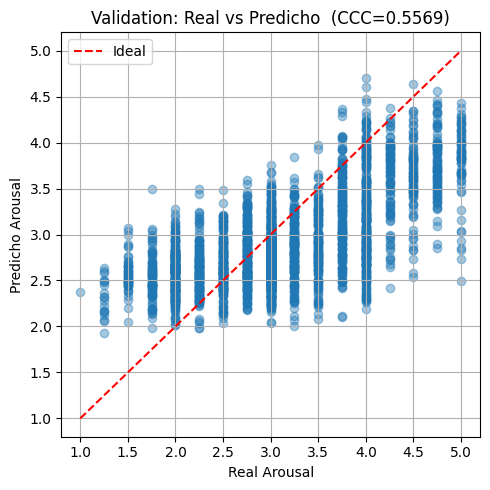

In [ ]:
import matplotlib.pyplot as plt

# --- Scatter VAL con línea ideal ---
min_v = min(y_true_va.min(), y_pred_va.min())
max_v = max(y_true_va.max(), y_pred_va.max())

plt.figure(figsize=(5, 5))
plt.scatter(y_true_va, y_pred_va, alpha=0.4)
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
plt.xlabel("Real Arousal")
plt.ylabel("Predicho Arousal")
plt.title(f"Validation: Real vs Predicho  (CCC={ccc_va:.4f})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

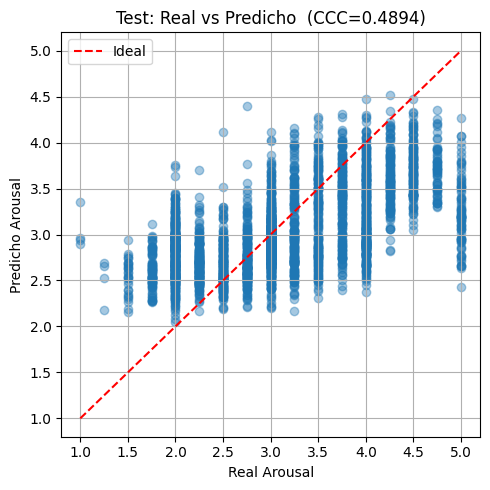

In [ ]:
# --- Scatter TEST con línea ideal ---
min_v = min(y_true_te.min(), y_pred_te.min())
max_v = max(y_true_te.max(), y_pred_te.max())

plt.figure(figsize=(5, 5))
plt.scatter(y_true_te, y_pred_te, alpha=0.4)
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
plt.xlabel("Real Arousal")
plt.ylabel("Predicho Arousal")
plt.title(f"Test: Real vs Predicho  (CCC={ccc_te:.4f})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

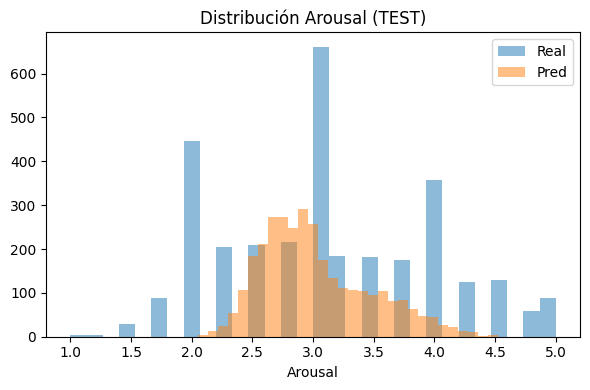

In [ ]:
# --- Histograma distribución real vs predicha (TEST) ---
plt.figure(figsize=(6, 4))
plt.hist(y_true_te, bins=30, alpha=0.5, label="Real")
plt.hist(y_pred_te, bins=30, alpha=0.5, label="Pred")
plt.legend()
plt.title("Distribución Arousal (TEST)")
plt.xlabel("Arousal")
plt.tight_layout()
plt.show()

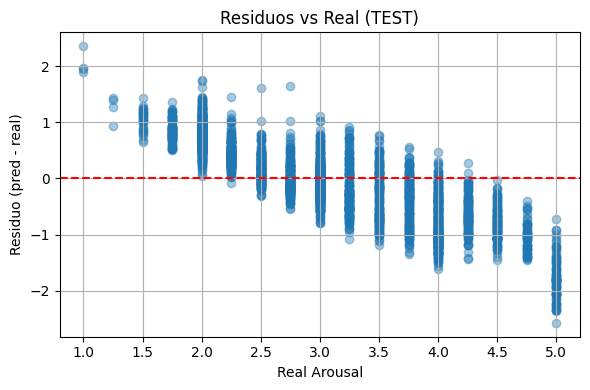

In [ ]:
# --- Residuos vs real (TEST) ---
residuals = y_pred_te - y_true_te

plt.figure(figsize=(6, 4))
plt.scatter(y_true_te, residuals, alpha=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Real Arousal")
plt.ylabel("Residuo (pred - real)")
plt.title("Residuos vs Real (TEST)")
plt.grid()
plt.tight_layout()
plt.show()

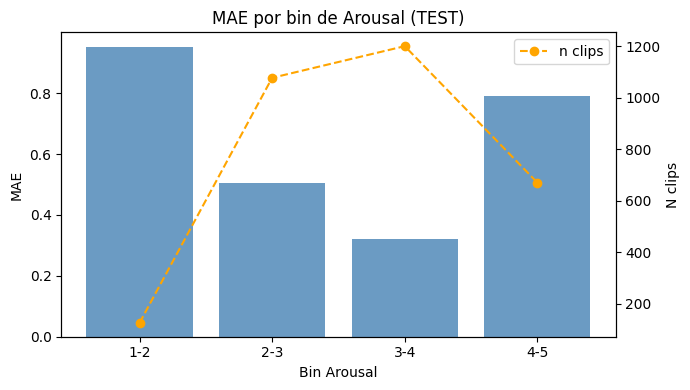

In [ ]:
# --- MAE por bin visual (TEST) ---
bins = [1, 2, 3, 4, 5]
labels_bin = []
maes_bin = []
counts_bin = []

for i in range(len(bins) - 1):
    mask = (y_true_te >= bins[i]) & (y_true_te < bins[i+1])
    if np.sum(mask) > 0:
        labels_bin.append(f"{bins[i]}-{bins[i+1]}")
        maes_bin.append(np.mean(np.abs(y_true_te[mask] - y_pred_te[mask])))
        counts_bin.append(np.sum(mask))

fig, ax1 = plt.subplots(figsize=(7, 4))
bars = ax1.bar(labels_bin, maes_bin, color='steelblue', alpha=0.8)
ax1.set_xlabel("Bin Arousal")
ax1.set_ylabel("MAE")
ax1.set_title("MAE por bin de Arousal (TEST)")

ax2 = ax1.twinx()
ax2.plot(labels_bin, counts_bin, 'o--', color='orange', label='n clips')
ax2.set_ylabel("N clips")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Guardar modelo y resultados

In [ ]:
import joblib
import json

joblib.dump(model_A_best, "model_A_best.joblib")

joblib.dump({
    "mu_X":   mu_X,
    "sd_X":   sd_X,
    "y_mean": y_mean,
    "y_std":  y_std
}, "norm_arousal.pkl")

with open("params_arousal.json", "w") as f:
    json.dump(best_params_arousal, f, indent=4)

results = {
    "ccc_val":       float(ccc_va),
    "ccc_test":      float(ccc_te),
    "best_trim":     BEST_TRIM,
    "best_iteration": best_iter_arousal,
}

with open("results_arousal.json", "w") as f:
    json.dump(results, f, indent=4)

np.savez_compressed(
    "preds_arousal.npz",
    pred_va=pred_va_denorm,
    pred_te=pred_te_denorm
)

print("Guardado: model_A_best.joblib, norm_arousal.pkl, params_arousal.json, results_arousal.json, preds_arousal.npz")

Guardado: model_A_best.joblib, norm_arousal.pkl, params_arousal.json, results_arousal.json, preds_arousal.npz


Calibracion

In [ ]:
from sklearn.isotonic import IsotonicRegression

y_true_va_clip = df_clip_va["true"].values.astype(np.float64)
y_pred_va_clip = df_clip_va["pred"].values.astype(np.float64)

cal = IsotonicRegression(out_of_bounds="clip", increasing=True)
cal.fit(y_pred_va_clip, y_true_va_clip)

print("Calibrador entrenado sobre", len(y_true_va_clip), "clips de validación")

Calibrador entrenado sobre 2945 clips de validación


In [ ]:
df_clip_va_cal = df_clip_va.copy()
df_clip_te_cal = df_clip_te.copy()

df_clip_va_cal["pred"] = cal.predict(df_clip_va["pred"].values)
df_clip_te_cal["pred"] = cal.predict(df_clip_te["pred"].values)

ccc_va_cal = ccc2(df_clip_va_cal["true"].values, df_clip_va_cal["pred"].values)
ccc_te_cal = ccc2(df_clip_te_cal["true"].values, df_clip_te_cal["pred"].values)

print(f"Sin calibración -> VAL CCC: {ccc_va:.4f} | TEST CCC: {ccc_te:.4f}")
print(f"Con calibración -> VAL CCC: {ccc_va_cal:.4f} | TEST CCC: {ccc_te_cal:.4f}")

Sin calibración -> VAL CCC: 0.5544 | TEST CCC: 0.4892
Con calibración -> VAL CCC: 0.6264 | TEST CCC: 0.5399


In [ ]:
report_all(df_clip_va_cal["true"].values, df_clip_va_cal["pred"].values, "VALIDATION (calibrado)")
report_all(df_clip_te_cal["true"].values, df_clip_te_cal["pred"].values, "TEST (calibrado)")

--- VALIDATION (calibrado) ---
CCC:          0.6264
MAE:          0.4911
RMSE:         0.6158
Bias:         0.0000
Std(pred):    0.5639
Corr(Pearson):0.6753

--- TEST (calibrado) ---
CCC:          0.5399
MAE:          0.5465
RMSE:         0.6984
Bias:         0.1032
Std(pred):    0.5503
Corr(Pearson):0.6018



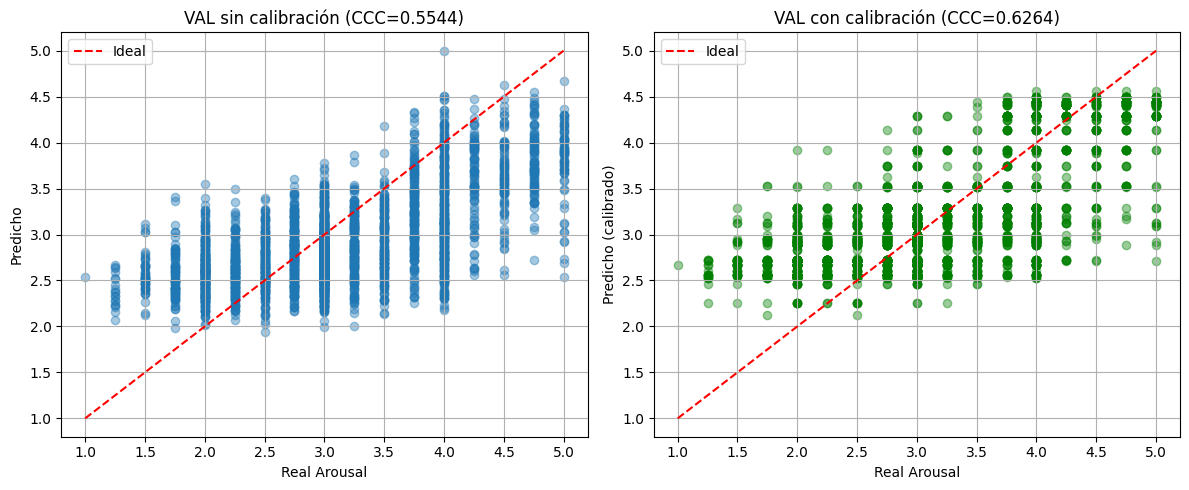

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sin calibración
ax = axes[0]
min_v = min(y_true_va_clip.min(), y_pred_va_clip.min())
max_v = max(y_true_va_clip.max(), y_pred_va_clip.max())
ax.scatter(y_true_va_clip, y_pred_va_clip, alpha=0.4)
ax.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
ax.set_xlabel("Real Arousal")
ax.set_ylabel("Predicho")
ax.set_title(f"VAL sin calibración (CCC={ccc_va:.4f})")
ax.legend()
ax.grid()

# Con calibración
y_pred_va_cal = df_clip_va_cal["pred"].values
ax = axes[1]
min_v = min(y_true_va_clip.min(), y_pred_va_cal.min())
max_v = max(y_true_va_clip.max(), y_pred_va_cal.max())
ax.scatter(y_true_va_clip, y_pred_va_cal, alpha=0.4, color='green')
ax.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
ax.set_xlabel("Real Arousal")
ax.set_ylabel("Predicho (calibrado)")
ax.set_title(f"VAL con calibración (CCC={ccc_va_cal:.4f})")
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

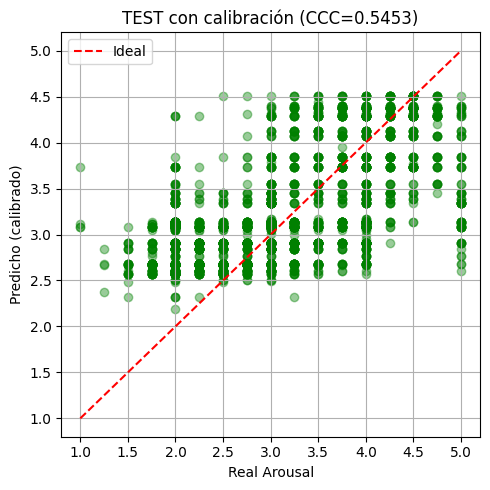

In [ ]:
y_true_te_clip = df_clip_te_cal["true"].values
y_pred_te_cal  = df_clip_te_cal["pred"].values

min_v = min(y_true_te_clip.min(), y_pred_te_cal.min())
max_v = max(y_true_te_clip.max(), y_pred_te_cal.max())

plt.figure(figsize=(5, 5))
plt.scatter(y_true_te_clip, y_pred_te_cal, alpha=0.4, color='green')
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
plt.xlabel("Real Arousal")
plt.ylabel("Predicho (calibrado)")
plt.title(f"TEST con calibración (CCC={ccc_te_cal:.4f})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

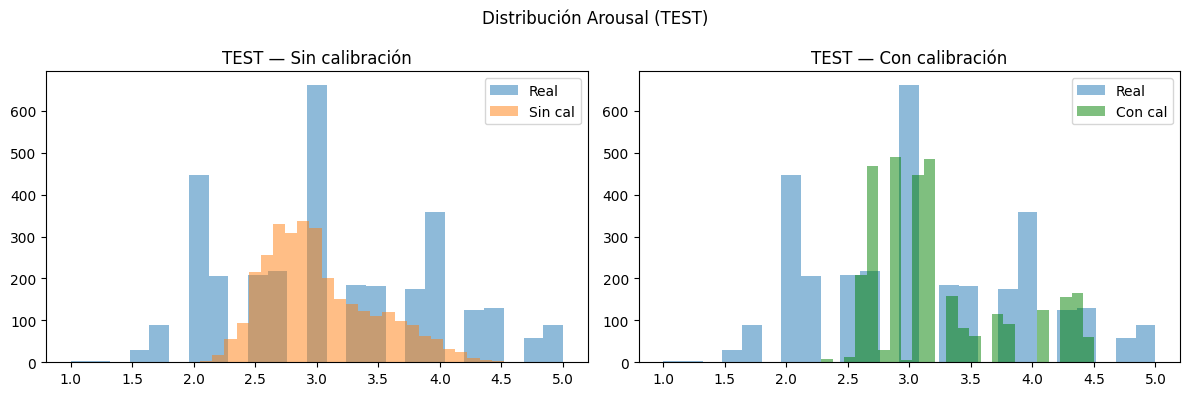

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_true_te_clip, bins=25, alpha=0.5, label="Real")
axes[0].hist(df_clip_te["pred"].values, bins=25, alpha=0.5, label="Sin cal")
axes[0].set_title("TEST — Sin calibración")
axes[0].legend()

axes[1].hist(y_true_te_clip, bins=25, alpha=0.5, label="Real")
axes[1].hist(y_pred_te_cal, bins=25, alpha=0.5, label="Con cal", color='green')
axes[1].set_title("TEST — Con calibración")
axes[1].legend()

plt.suptitle("Distribución Arousal (TEST)")
plt.tight_layout()
plt.show()

In [ ]:
import joblib, json

joblib.dump(cal, "calibrator_arousal.joblib")

results_cal = {
    "ccc_val_uncal":  float(ccc_va),
    "ccc_test_uncal": float(ccc_te),
    "ccc_val_cal":    float(ccc_va_cal),
    "ccc_test_cal":   float(ccc_te_cal),
    "best_trim":      BEST_TRIM,
    "best_iteration": best_iter_arousal,
}

with open("results_arousal.json", "w") as f:
    json.dump(results_cal, f, indent=4)

print("Guardado: calibrator_arousal.joblib, results_arousal.json")

Guardado: calibrator_arousal.joblib, results_arousal.json


In [ ]:
np.savez_compressed(
    "preds_arousal.npz",
    pred_va=df_clip_va_cal["pred"].values,
    pred_te=df_clip_te_cal["pred"].values,
    pred_va_uncal=pred_va_denorm,
    pred_te_uncal=pred_te_denorm,
)

In [ ]:
# Guardar pesos del modelo XGBoost
model_A_w.save_model("model_arousal.ubj")

import numpy as np
np.savez_compressed(
    "scaler_arousal.npz",
    mu_X   = mu_X,
    sd_X   = sd_X,
    y_mean = np.array([y_mean]),
    y_std  = np.array([y_std]),
)

print("Listo!")

Listo!


In [ ]:
import joblib, json

# El modelo correcto: entrenado con pesos (sample_weight)
joblib.dump(model_A_w, "model_A_w.joblib")

# Normalizadores
joblib.dump({
    "mu_X":   mu_X,
    "sd_X":   sd_X,
    "y_mean": y_mean,
    "y_std":  y_std
}, "norm_arousal.pkl")

# Calibrador
joblib.dump(cal, "calibrator_arousal.joblib")

print("Guardado: model_A_w.joblib, norm_arousal.pkl, calibrator_arousal.joblib")

Guardado: model_A_w.joblib, norm_arousal.pkl, calibrator_arousal.joblib
